In [3]:
import pandas as pd
df = pd.read_csv('dataset_task2.csv')

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
df.shape

(200, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [13]:
df = df.drop_duplicates()

In [15]:
df.shape

(200, 5)

In [17]:
df.drop(columns=['CustomerID'], inplace=True)

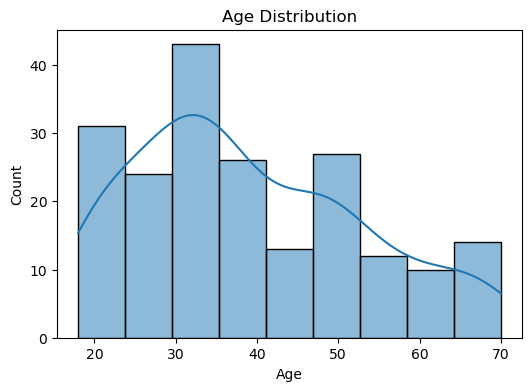

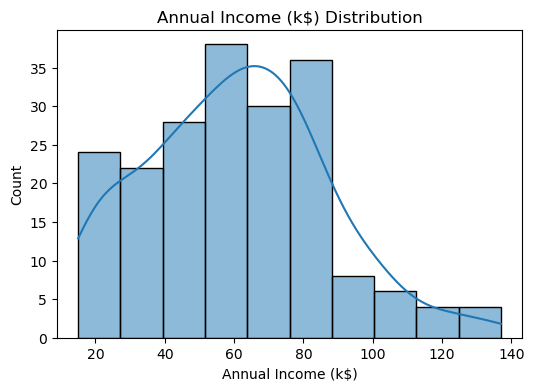

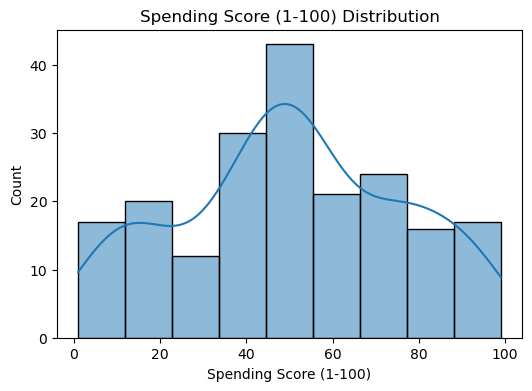

In [19]:
#Numerical features
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14412\3520344185.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='coolwarm')


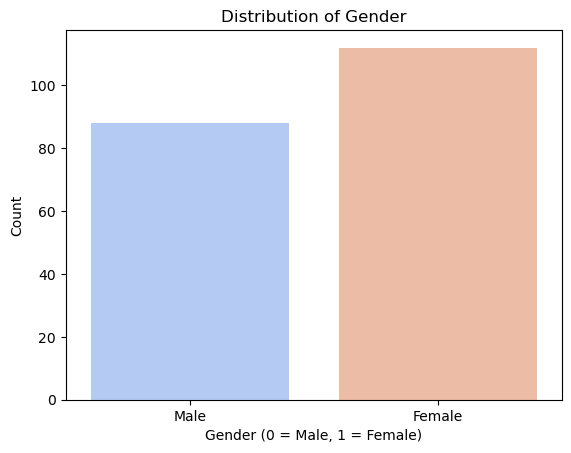

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Gender', data=df, palette='coolwarm')
plt.title('Distribution of Gender')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.ylabel('Count')
plt.show()

In [23]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [25]:
X= (df[['Annual Income (k$)', 'Spending Score (1-100)']])

In [27]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

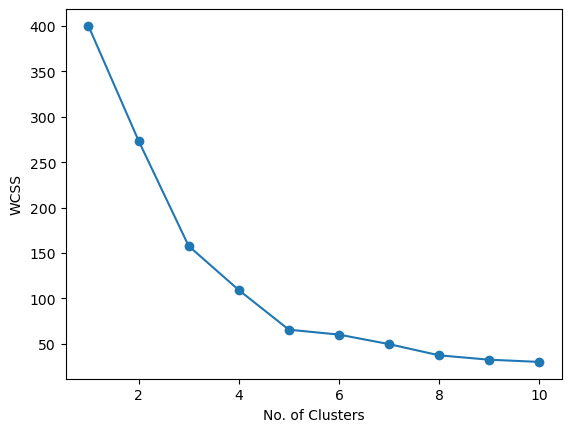

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss= []
for k in range(1,11):
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss, marker='o')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

In [31]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster']= kmeans.fit_predict(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


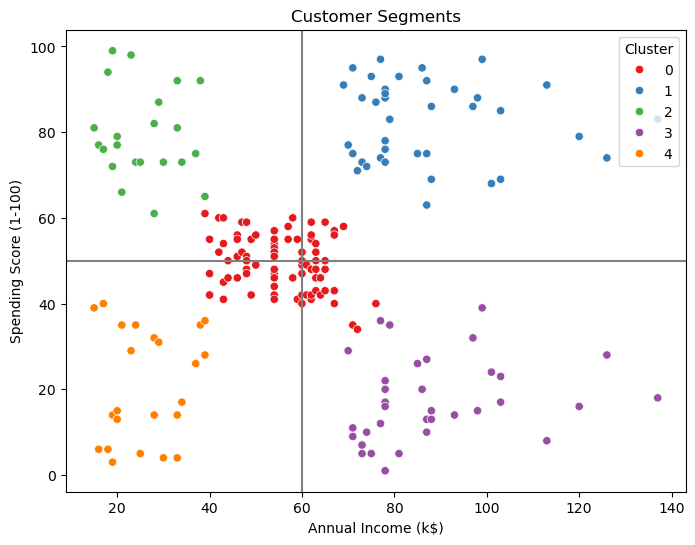

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue= df['Cluster'],
    palette='Set1'
    )
plt.axhline(50, color='gray')
plt.axvline(60, color='gray')
plt.title('Customer Segments')
plt.show()

In [35]:
#Blue customers are the most important customers: High income, high spending
#Purple customers can afford much more but they dont spend
#Orange customers dont have a high spending power due to low income
#Green customers spend a lot despite low income.
#Red customers are the average spenders with the average income.

In [37]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df['Cluster']

sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz Score:", ch)

Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Score: 248.64932001536357


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [41]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,4
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,2
4,1,31,17,40,4


In [43]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

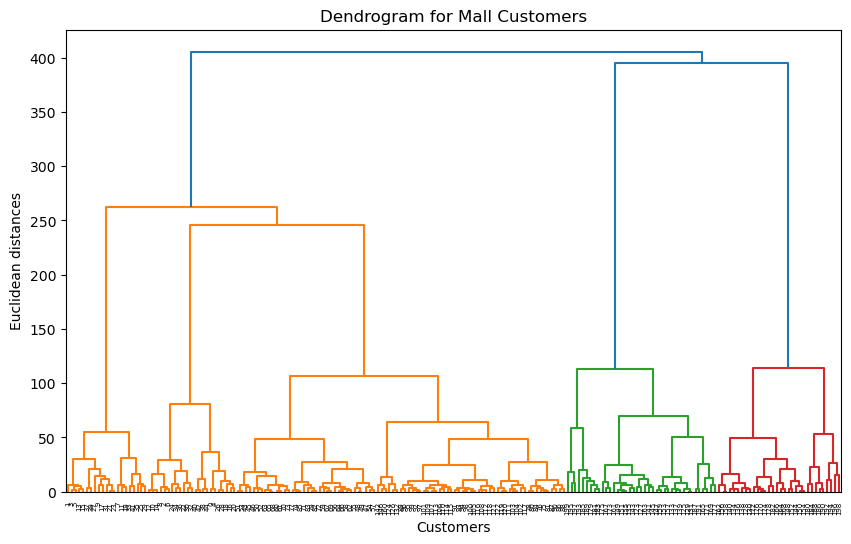

In [45]:
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title('Dendrogram for Mall Customers')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [47]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(x)
df['Cluster'] = y_hc

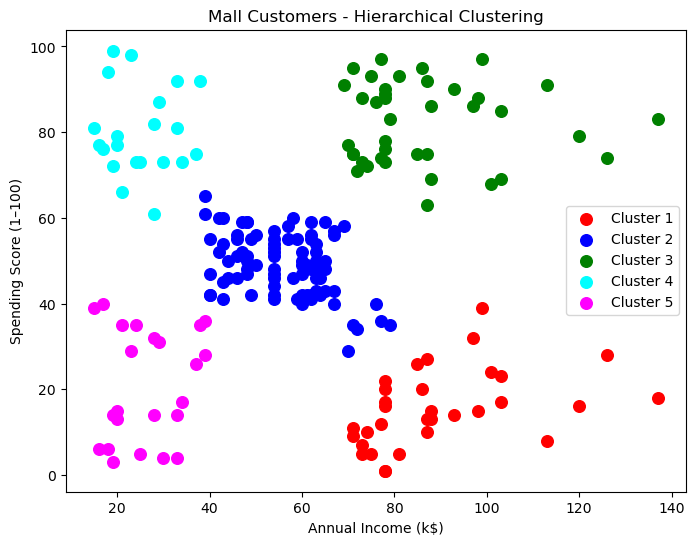

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(x[y_hc == 0, 0], x[y_hc == 0, 1], s=70, c='red', label='Cluster 1')
plt.scatter(x[y_hc == 1, 0], x[y_hc == 1, 1], s=70, c='blue', label='Cluster 2')
plt.scatter(x[y_hc == 2, 0], x[y_hc == 2, 1], s=70, c='green', label='Cluster 3')
plt.scatter(x[y_hc == 3, 0], x[y_hc == 3, 1], s=70, c='cyan', label='Cluster 4')
plt.scatter(x[y_hc == 4, 0], x[y_hc == 4, 1], s=70, c='magenta', label='Cluster 5')
plt.title('Mall Customers - Hierarchical Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend()
plt.show()

In [51]:
#Green customers are the most important customers: High income, high spending
#Red customers can afford much more but they dont spend
#Pink customers dont have a high spending power due to low income
#Cyan customers spend a lot despite low income.
#Blue customers are the average spenders with the average income.

In [53]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df['Cluster']

sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz Score:", ch)

Silhouette Score: 0.5538089226688662
Davies-Bouldin Index: 0.5778621190740154
Calinski-Harabasz Score: 244.4103258659682


In [55]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

In [57]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [59]:
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

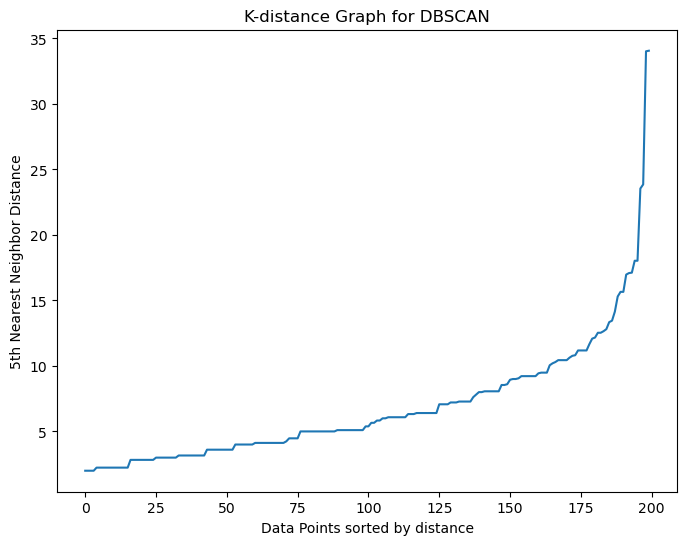

In [61]:
distances = np.sort(distances[:, 4])
plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.show()

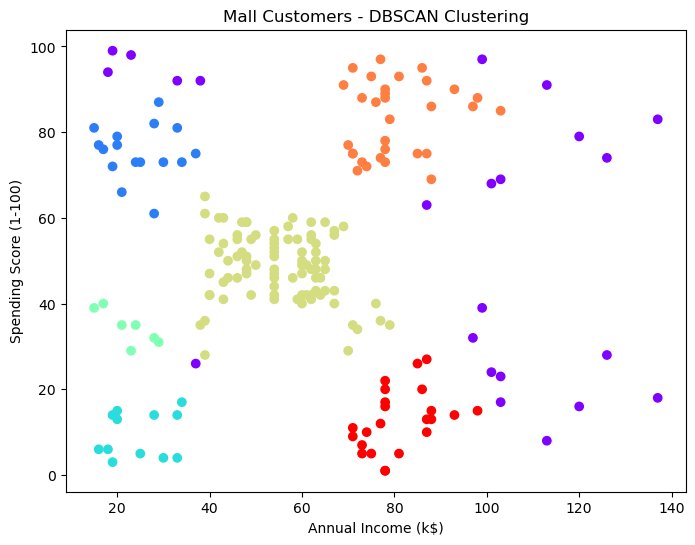

In [73]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=9, min_samples=5)
labels = dbscan.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.title('Mall Customers - DBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [71]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
sil = silhouette_score(X_scaled, label)
dbi = davies_bouldin_score(X_scaled, label)
ch = calinski_harabasz_score(X_scaled, label)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz Score:", ch)

Silhouette Score: 0.436768048377307
Davies-Bouldin Index: 1.327850509733628
Calinski-Harabasz Score: 74.71401745575844


In [79]:
!pip install hdbscan

   ---------------------------------------- 0.0/726.2 kB ? eta -:--:--
   - ------------------------------------- 20.5/726.2 kB 682.7 kB/s eta 0:00:02
   --- ----------------------------------- 71.7/726.2 kB 660.6 kB/s eta 0:00:01
   ---------- ----------------------------- 184.3/726.2 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------  716.8/726.2 kB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 726.2/726.2 kB 3.1 MB/s eta 0:00:00


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



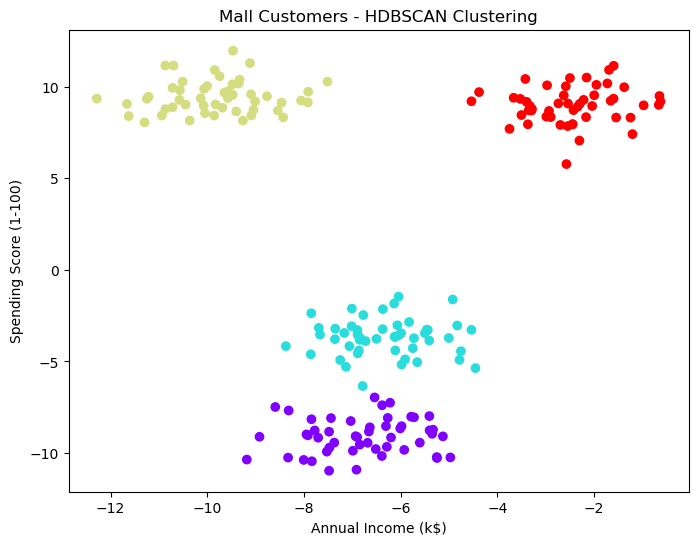

In [81]:
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=5,min_samples=None,metric='euclidean',cluster_selection_method='leaf')
labels = hdb.fit_predict(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.title('Mall Customers - HDBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [83]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", dbi)
print("Calinski-Harabasz Score:", ch)

Silhouette Score: 0.7493226806873509
Davies-Bouldin Index: 0.35738007111757175
Calinski-Harabasz Score: 1499.5022223041165
